# Customer Churn Prediction
A portfolio-ready end-to-end machine learning project using pandas, scikit-learn, matplotlib, and Jupyter Notebook.

**Objective:** predict customer churn and identify the strongest retention risk drivers in the Telco customer base.

## 1. Imports and Setup
This notebook uses a reusable analysis module so the workflow is easy to rerun as a script or present in a notebook.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from Customer_Churn import (
    clean_data,
    engineer_features,
    run_analysis,
)

pd.set_option('display.max_columns', None)
DATA_PATH = Path('Telco-Customer-Churn.csv')

## 2. Data Loading
Read the raw customer churn dataset and inspect the structure.

In [2]:
raw_df = pd.read_csv(DATA_PATH)
print(f'Shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns')
raw_df.head()

Shape: 7,043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
raw_df.info()

display(raw_df.describe(include='all').transpose().head(10))

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Preprocessing and Cleaning
Key tasks:
- fix `TotalCharges` data type and blank-string missing values
- standardize categorical values
- create a binary target column for modeling

In [4]:
cleaned_df = clean_data(raw_df)
cleaned_df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'ChurnLabel']].head()

,tenure,MonthlyCharges,TotalCharges,Churn,ChurnLabel
0,1,29.85,29.85,No,0
1,34,56.95,1889.50,No,0
2,2,53.85,108.15,Yes,1
3,45,42.30,1840.75,No,0
4,2,70.70,151.65,Yes,1


In [5]:
cleaned_df.isna().sum().sort_values(ascending=False).head(10)

customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64

## 4. Feature Engineering
Business-oriented features improve interpretability and model signal:
- `tenure_band`
- `total_services`
- `avg_monthly_charge_from_total`
- `monthly_to_total_ratio`
- simple customer state flags such as `is_new_customer`

In [6]:
featured_df = engineer_features(cleaned_df)
featured_df[
    [
        'tenure', 'tenure_band', 'MonthlyCharges', 'TotalCharges',
        'total_services', 'avg_monthly_charge_from_total',
        'monthly_to_total_ratio', 'is_new_customer', 'has_streaming_bundle'
    ]
].head()

,tenure,tenure_band,MonthlyCharges,TotalCharges,total_services,avg_monthly_charge_from_total,monthly_to_total_ratio,is_new_customer,has_streaming_bundle
0,1,0-12 months,29.85,29.85,1,29.850000,1.000000,Yes,No
1,34,25-48 months,56.95,1889.50,3,55.573529,0.030140,No,No
2,2,0-12 months,53.85,108.15,3,54.075000,0.497920,Yes,No
3,45,25-48 months,42.30,1840.75,3,40.905556,0.022980,No,No
4,2,0-12 months,70.70,151.65,1,75.825000,0.466205,Yes,No


## 5. Exploratory Analysis
Run the full pipeline once to create saved visual assets and model outputs.

In [7]:
results = run_analysis(DATA_PATH)
metrics_df = results['metrics_df']
logistic_df = results['logistic_df']
tree_df = results['tree_df']
featured_df = results['featured_df']
metrics_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.734564,0.500000,0.794118,0.613636,0.847384
1,Random Forest,0.772179,0.556025,0.703209,0.621015,0.840572


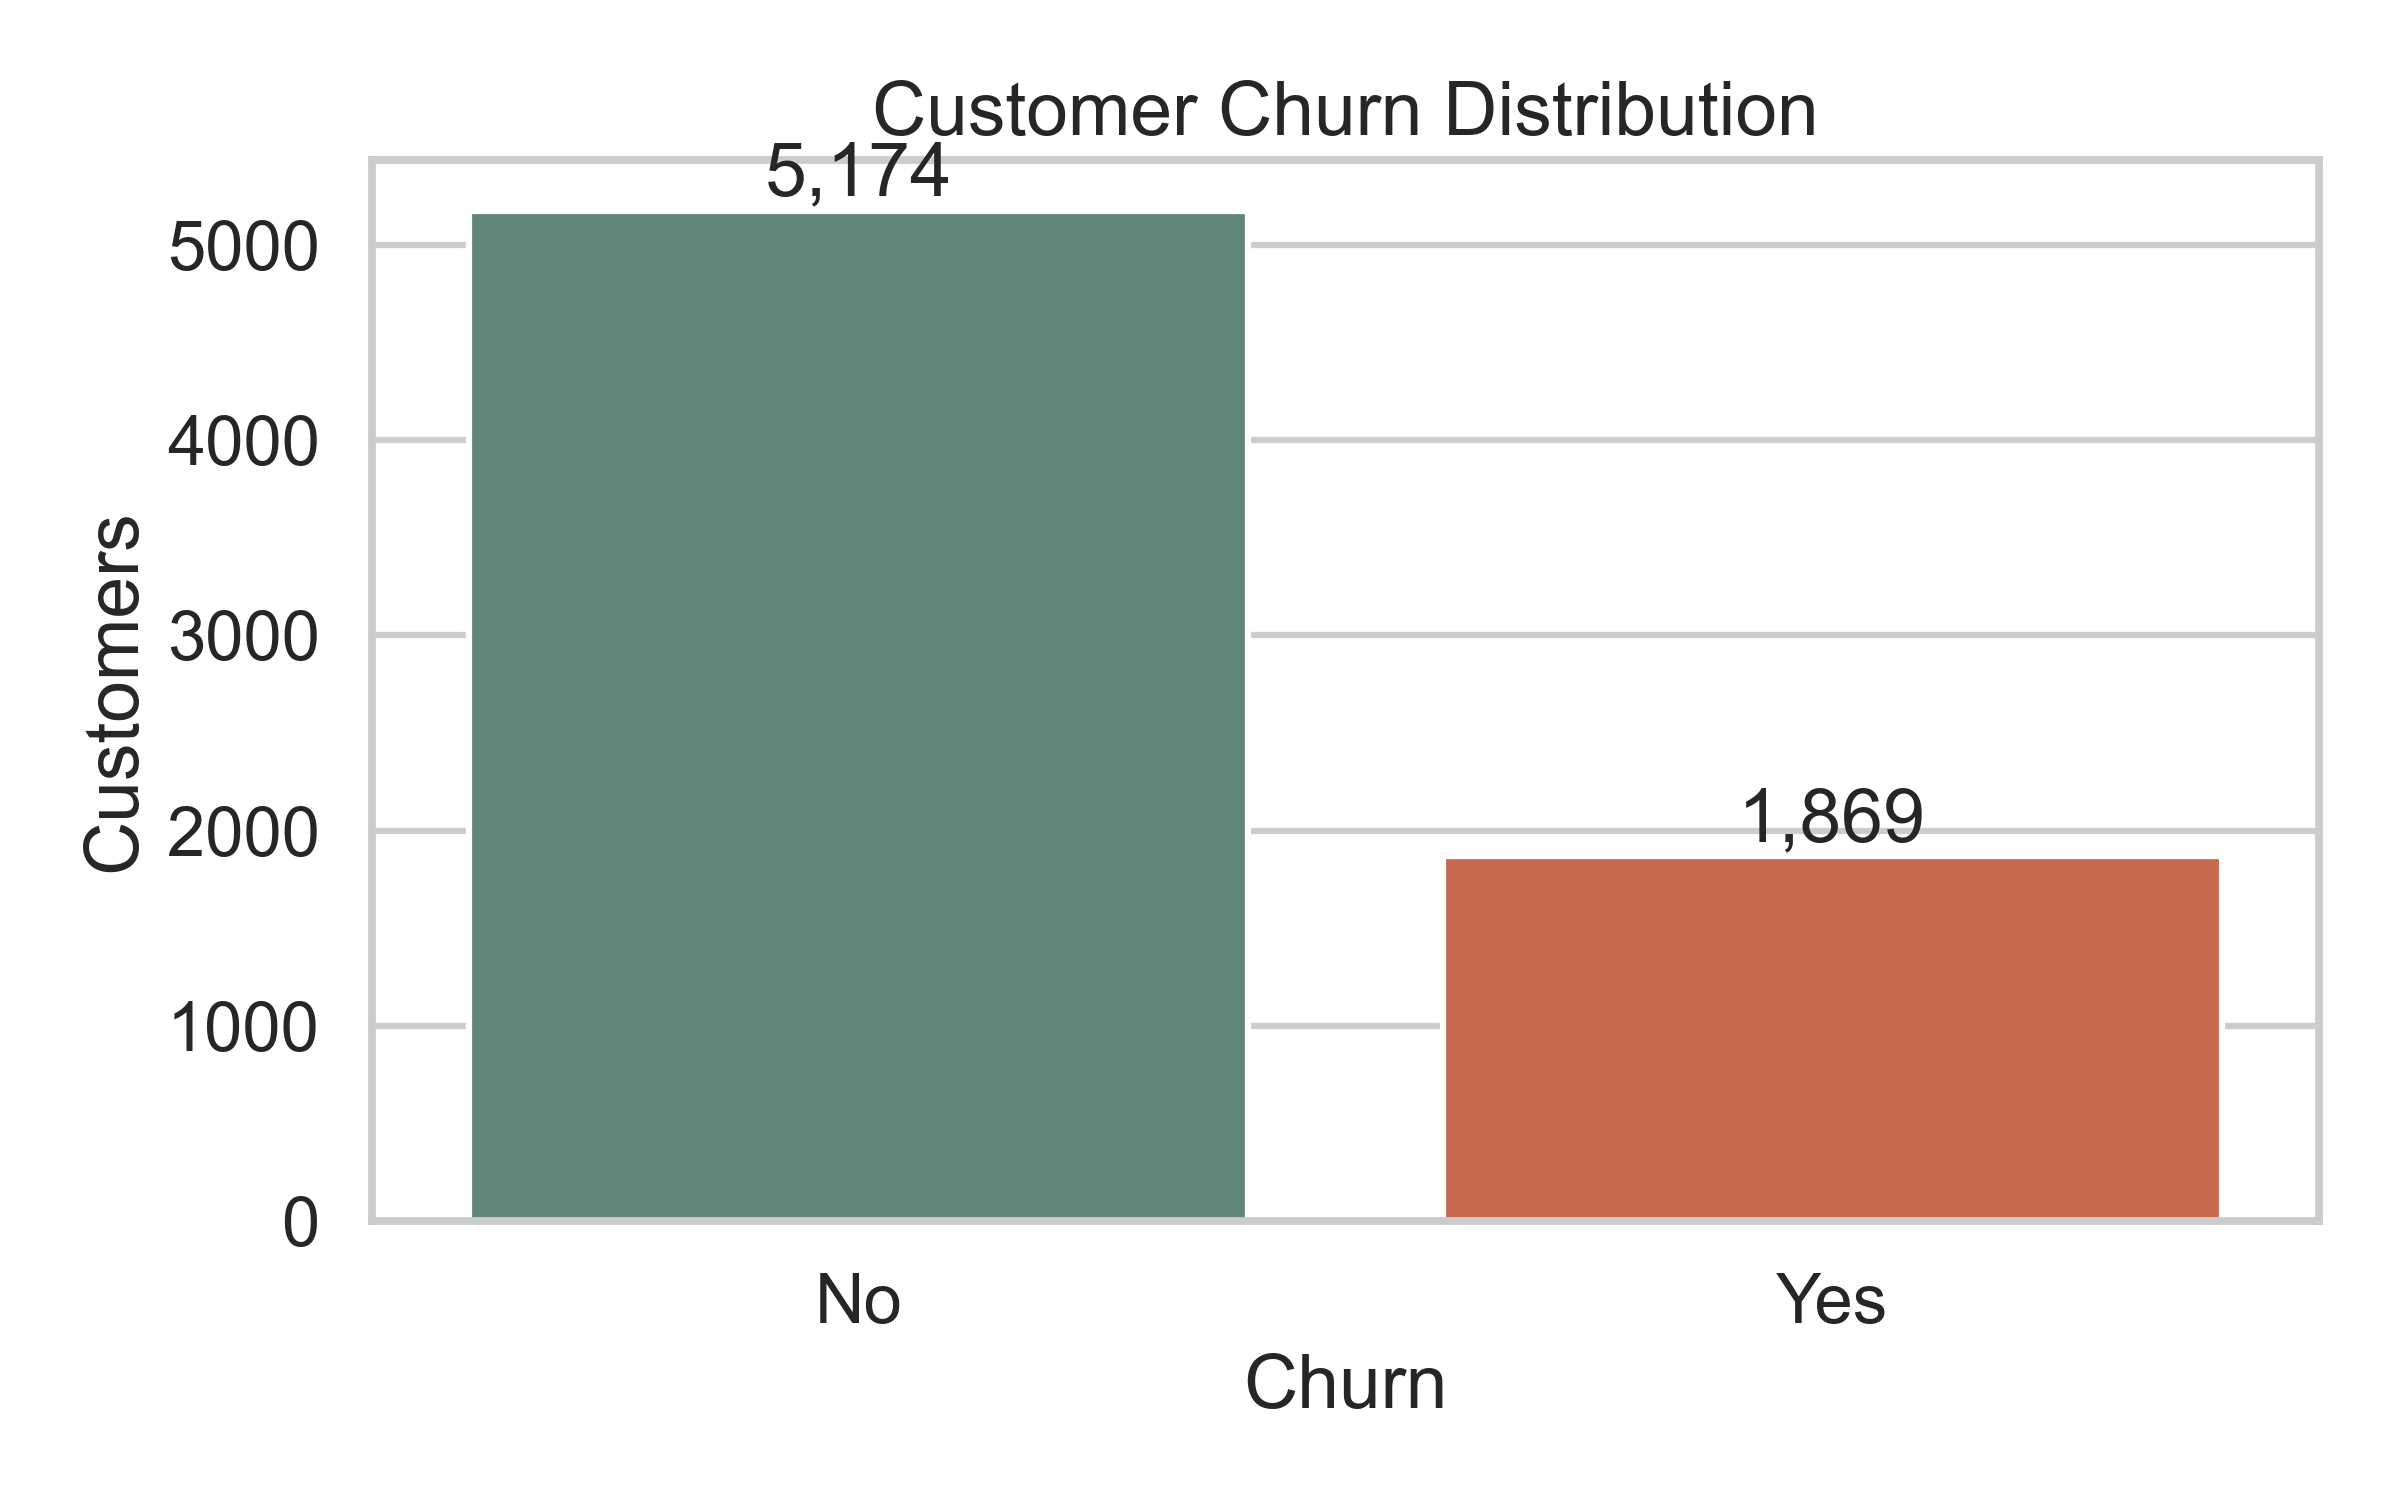

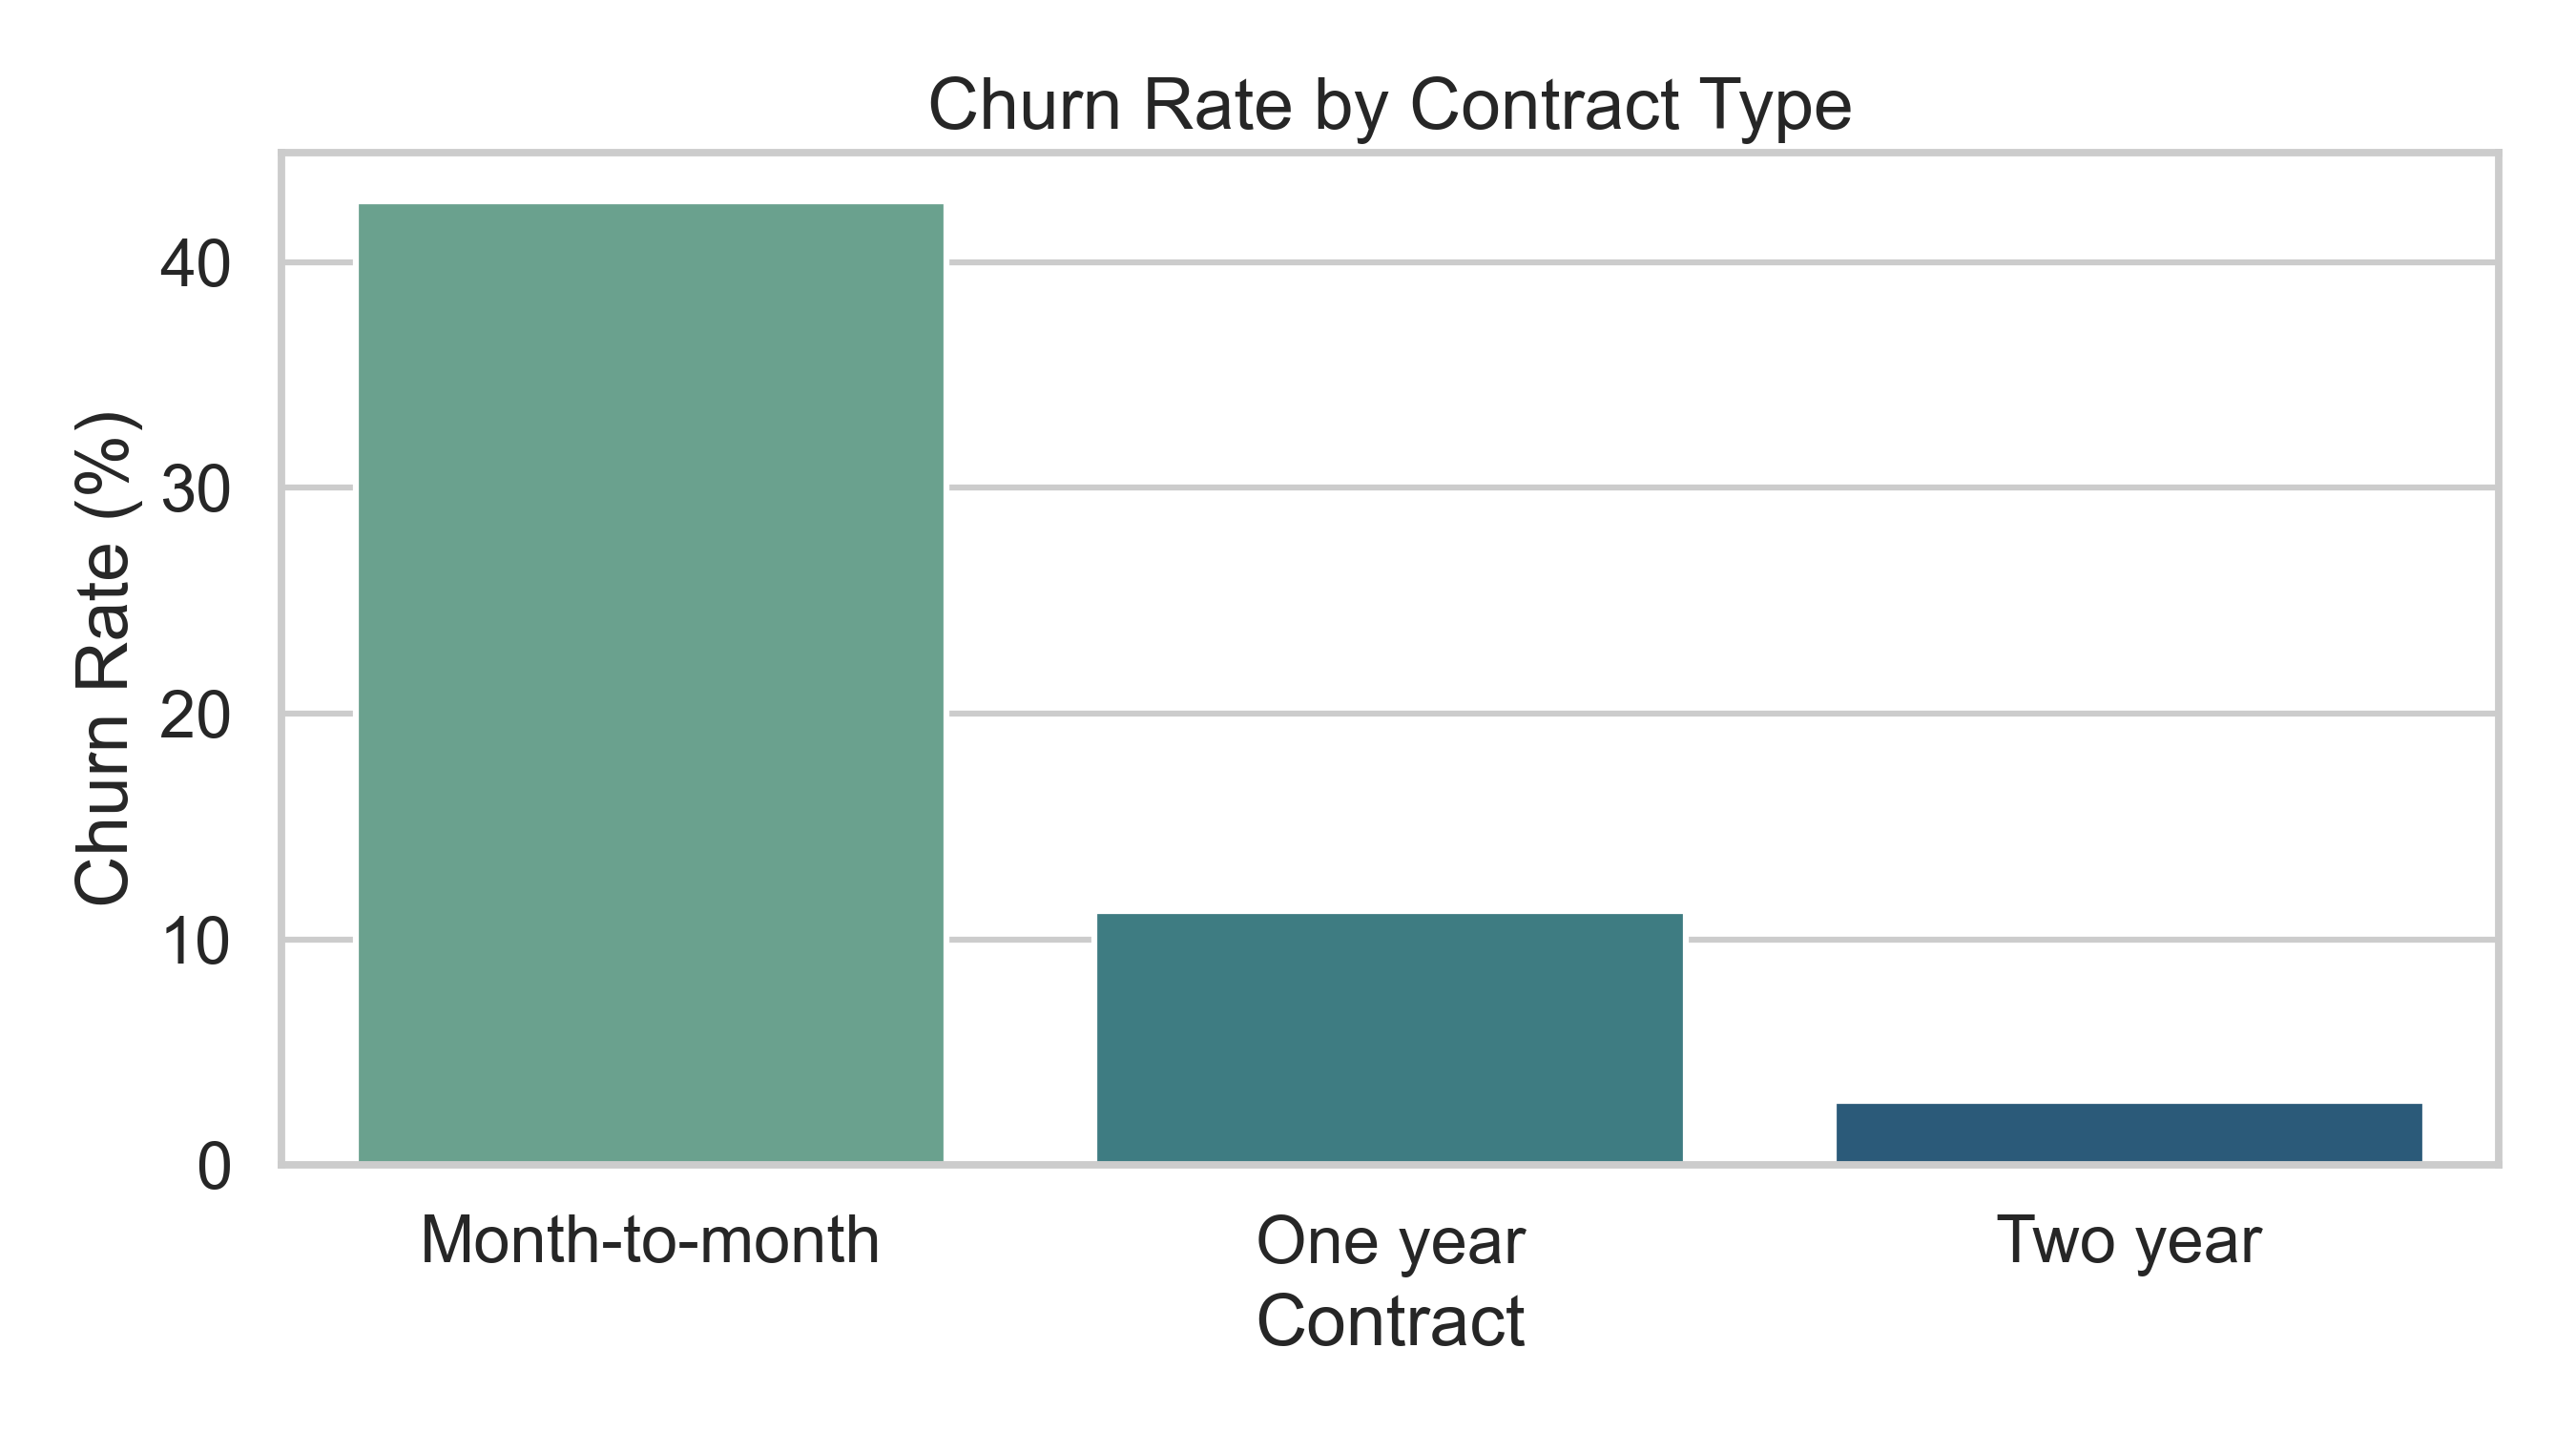

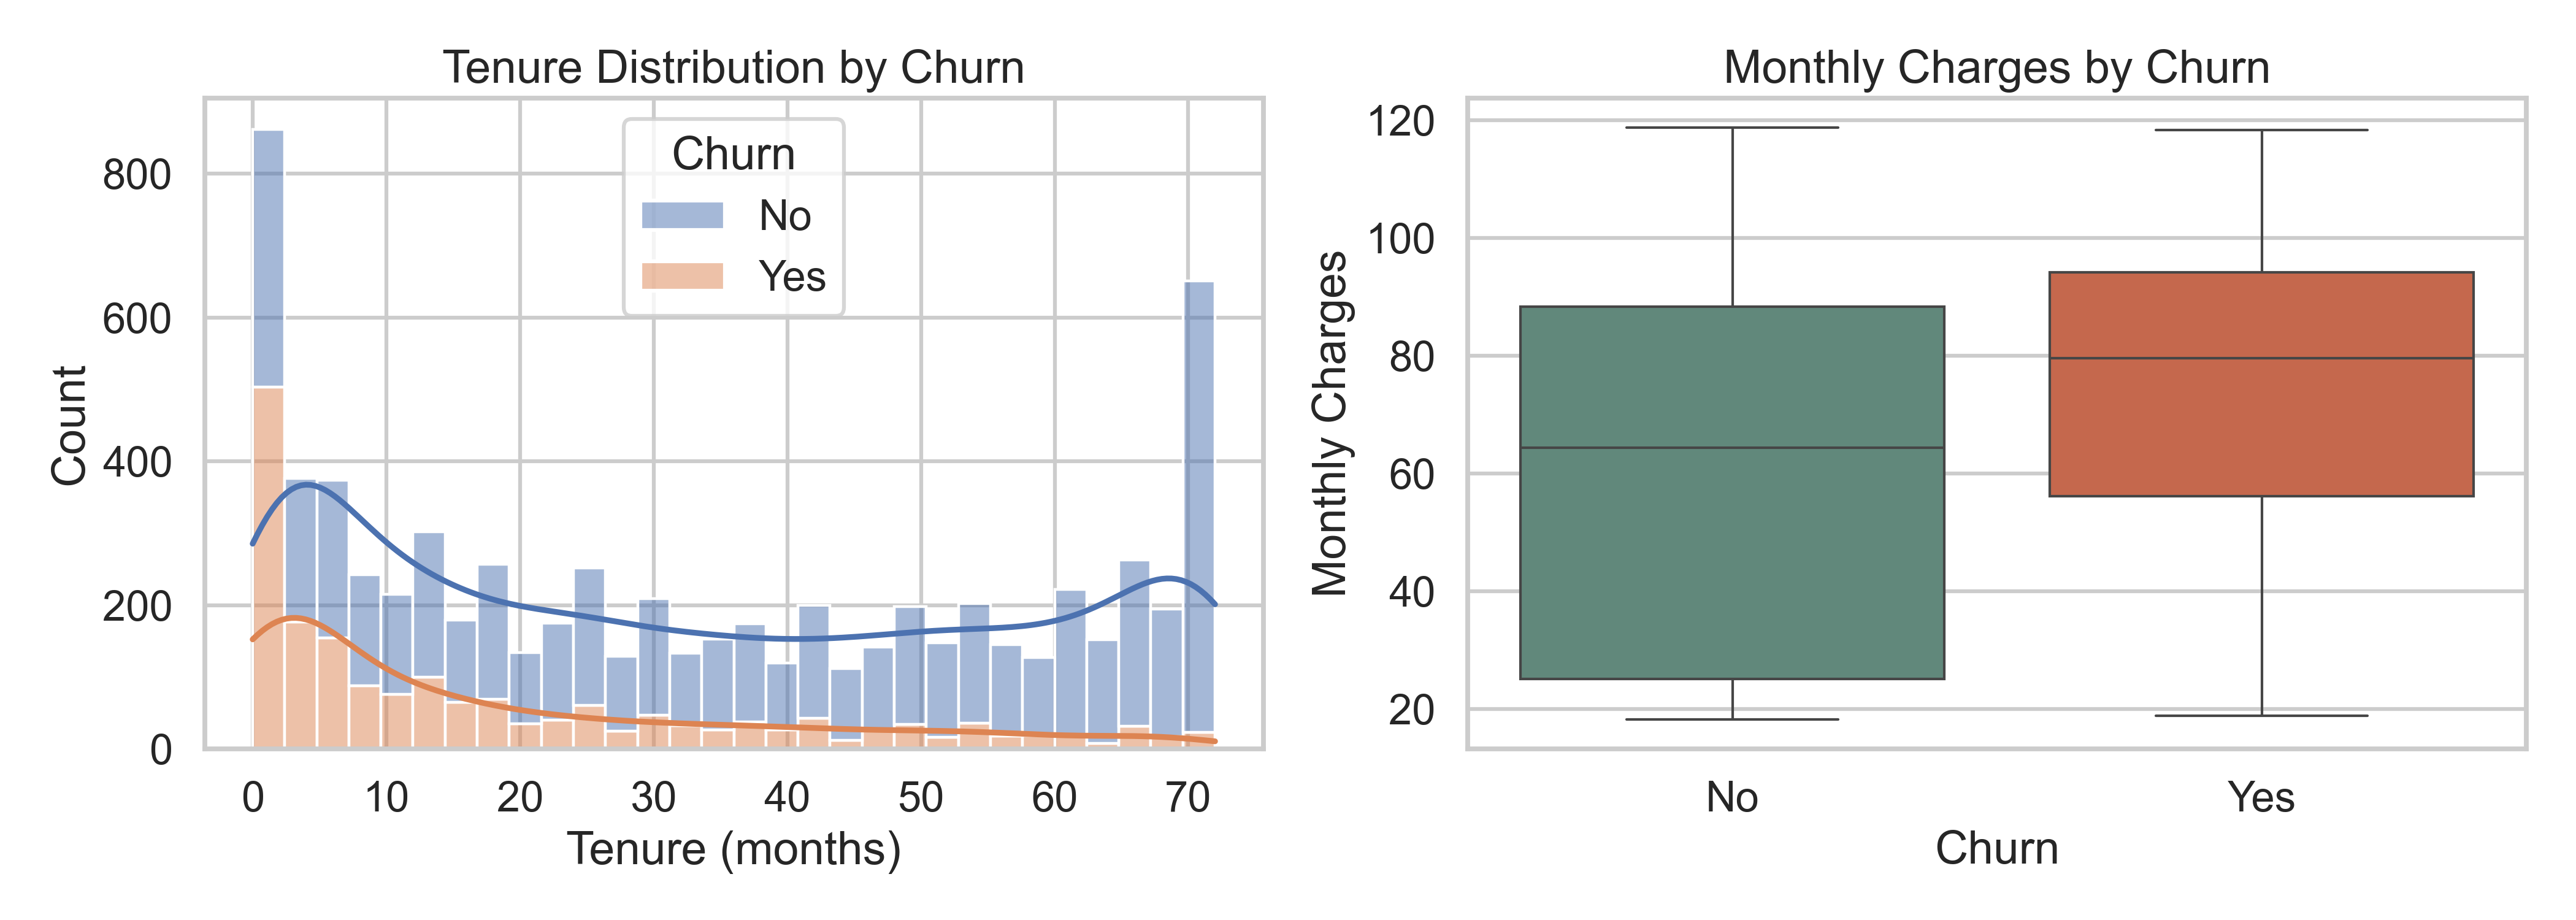

In [8]:
display(Image(filename='outputs/figures/churn_distribution.png'))
display(Image(filename='outputs/figures/contract_vs_churn.png'))
display(Image(filename='outputs/figures/tenure_and_charges.png'))

## 6. Model Training and Evaluation
Two models are compared:
- Logistic Regression for a strong baseline with interpretable coefficients
- Random Forest for a nonlinear tree-based benchmark

In [9]:
metrics_df.style.format({
    'accuracy': '{:.3f}',
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1_score': '{:.3f}',
    'roc_auc': '{:.3f}'
})

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.735,0.500,0.794,0.614,0.847
1,Random Forest,0.772,0.556,0.703,0.621,0.841


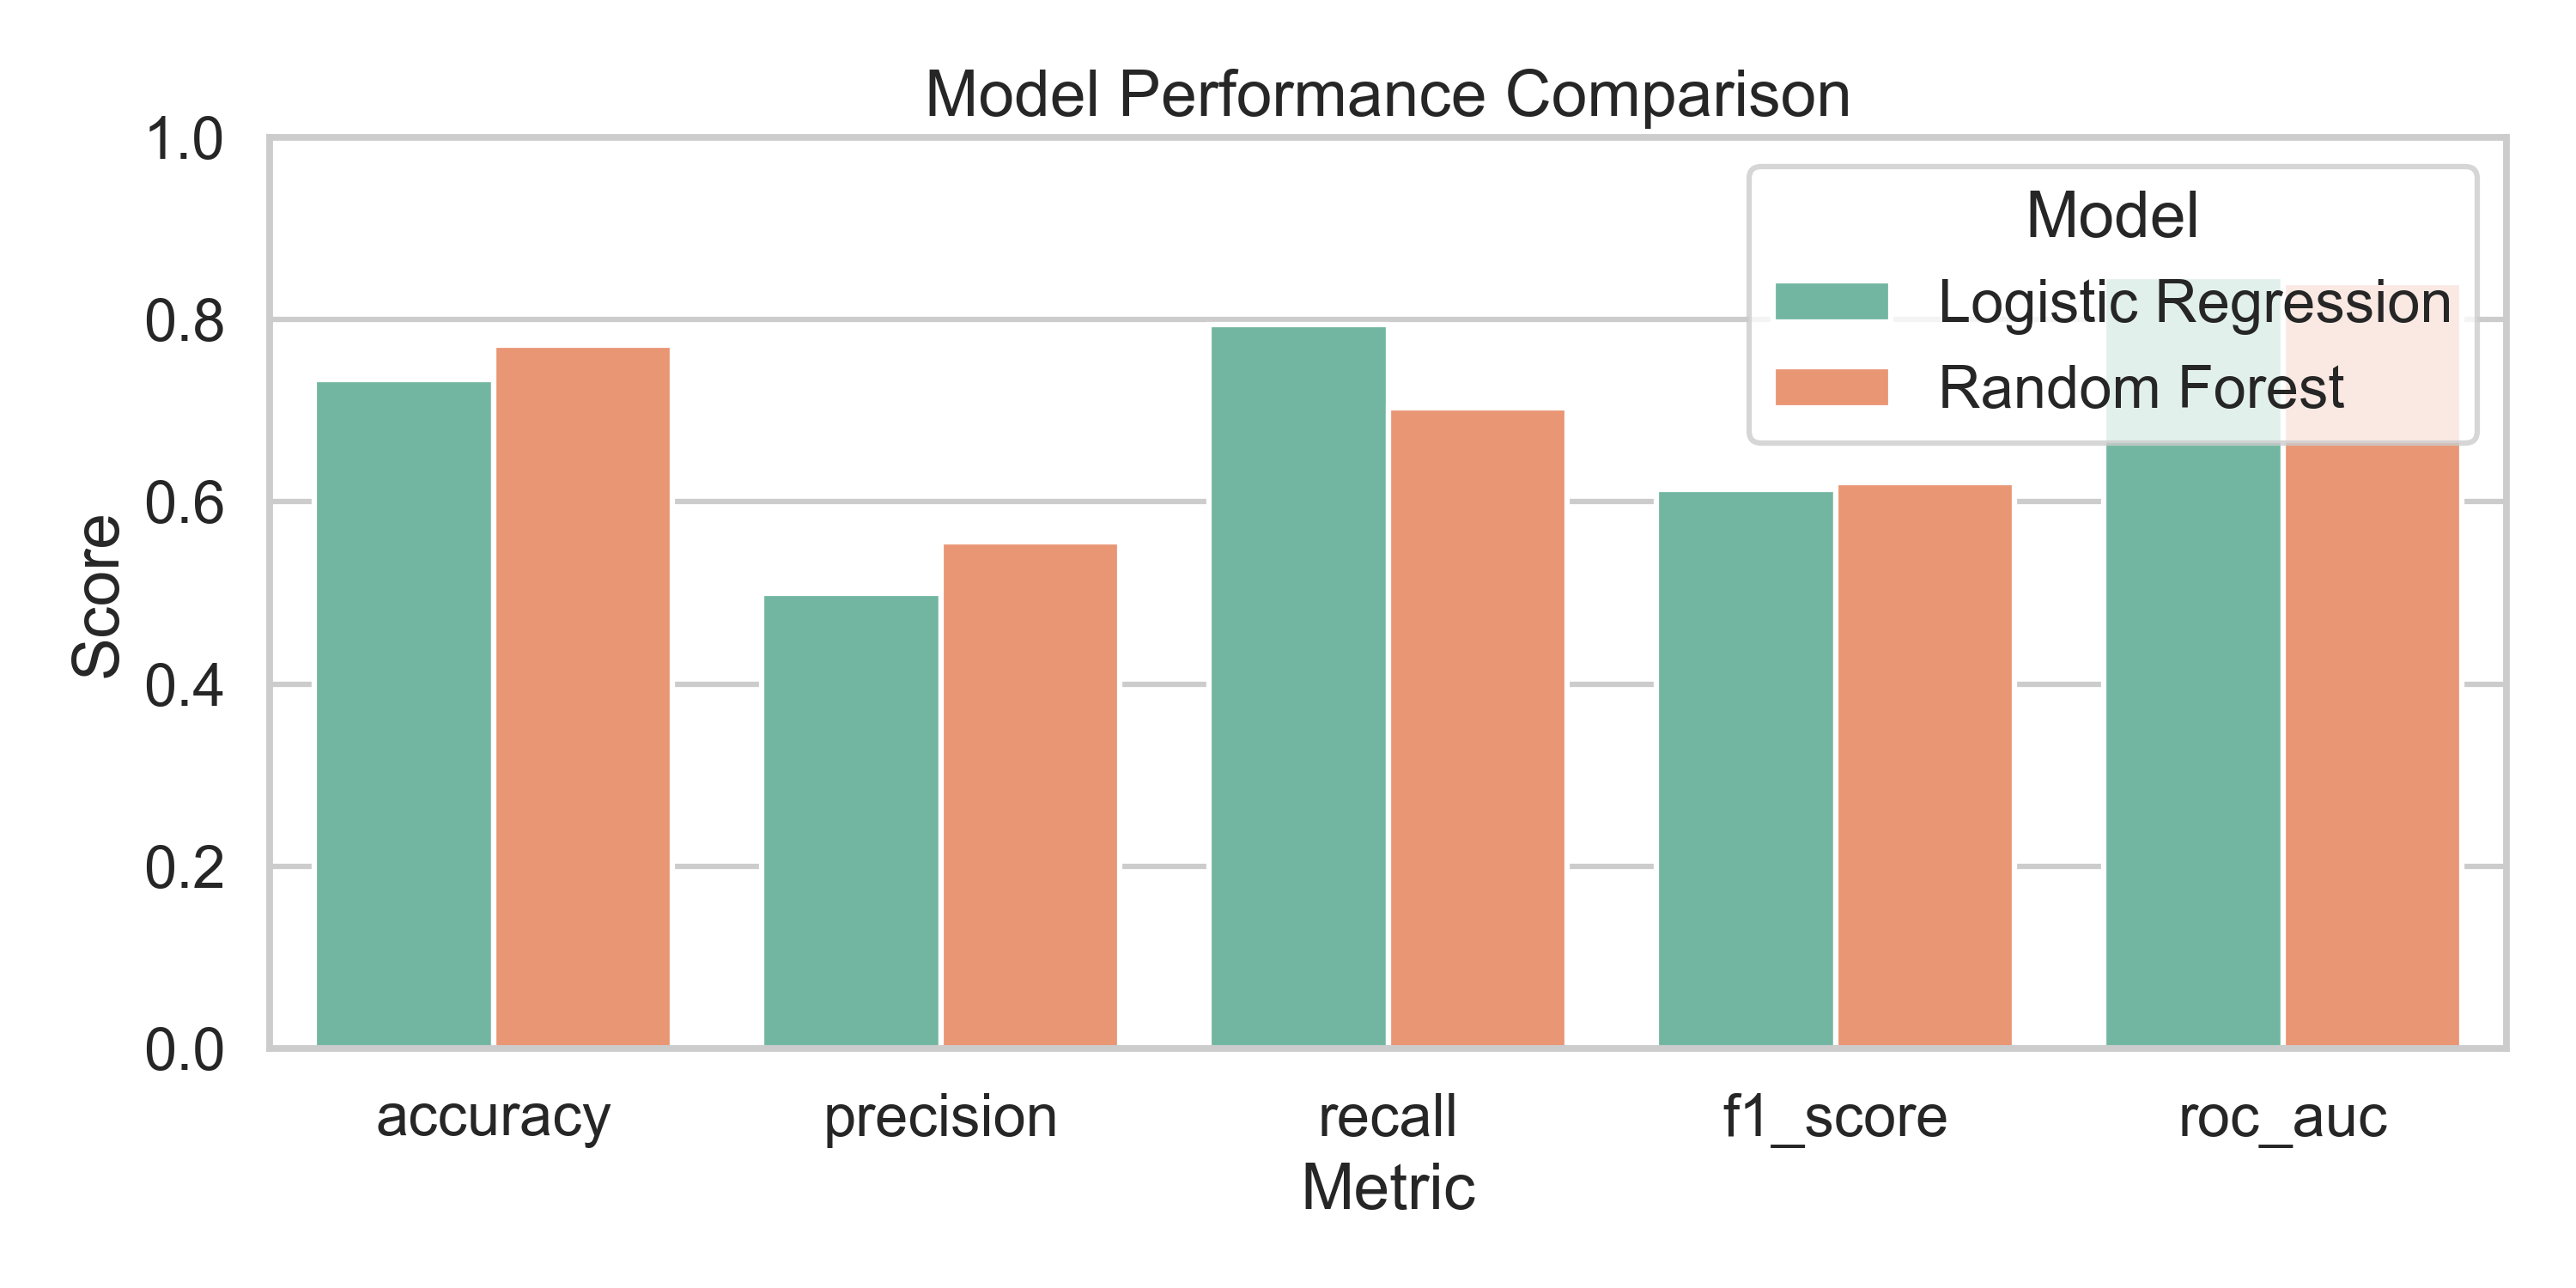

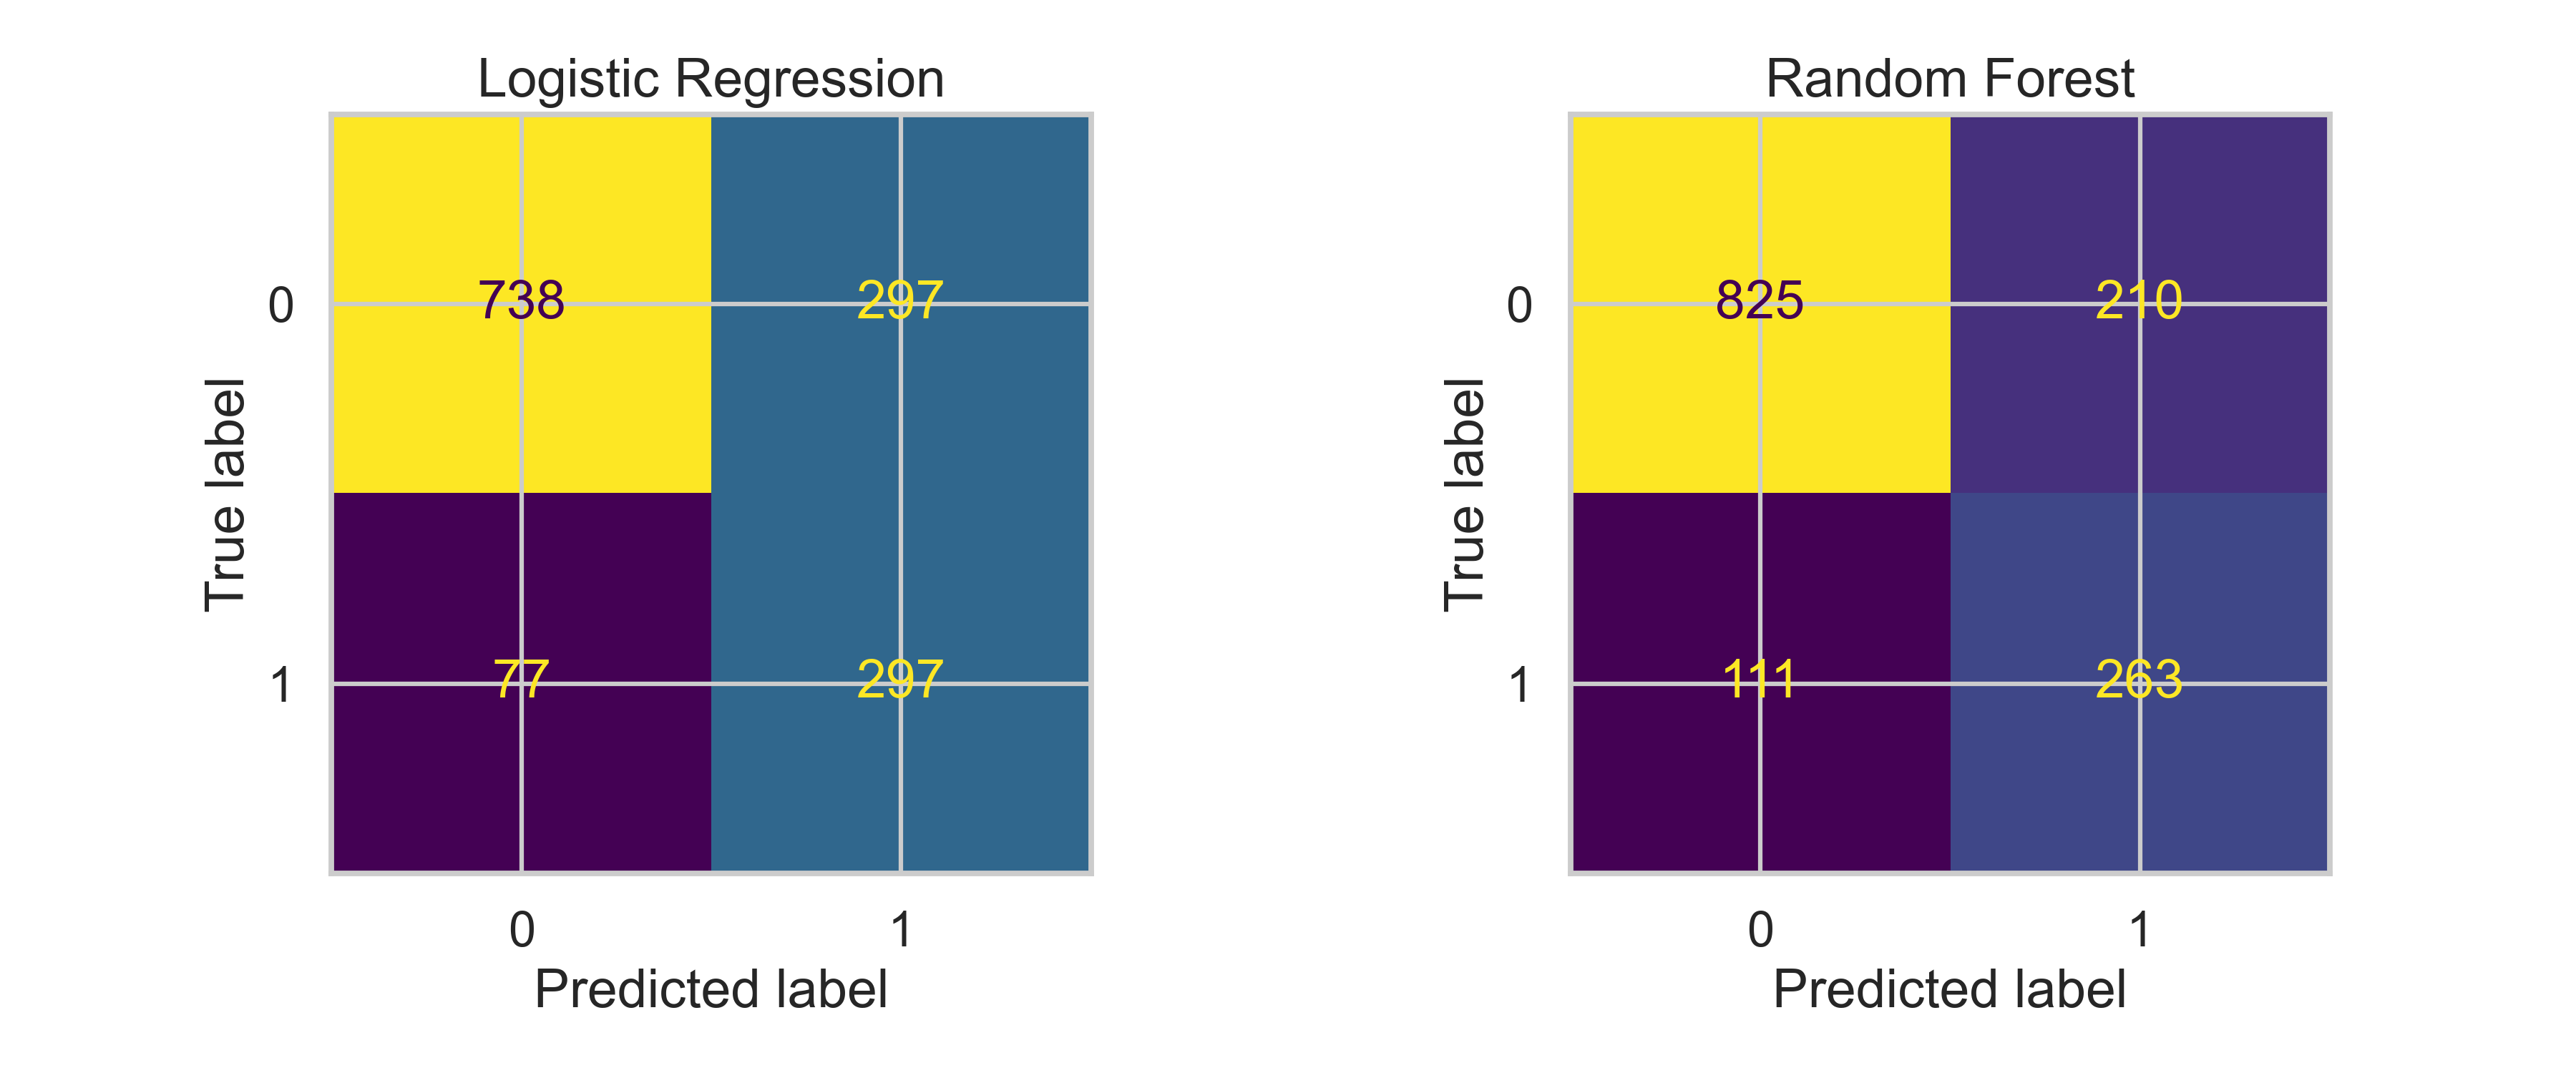

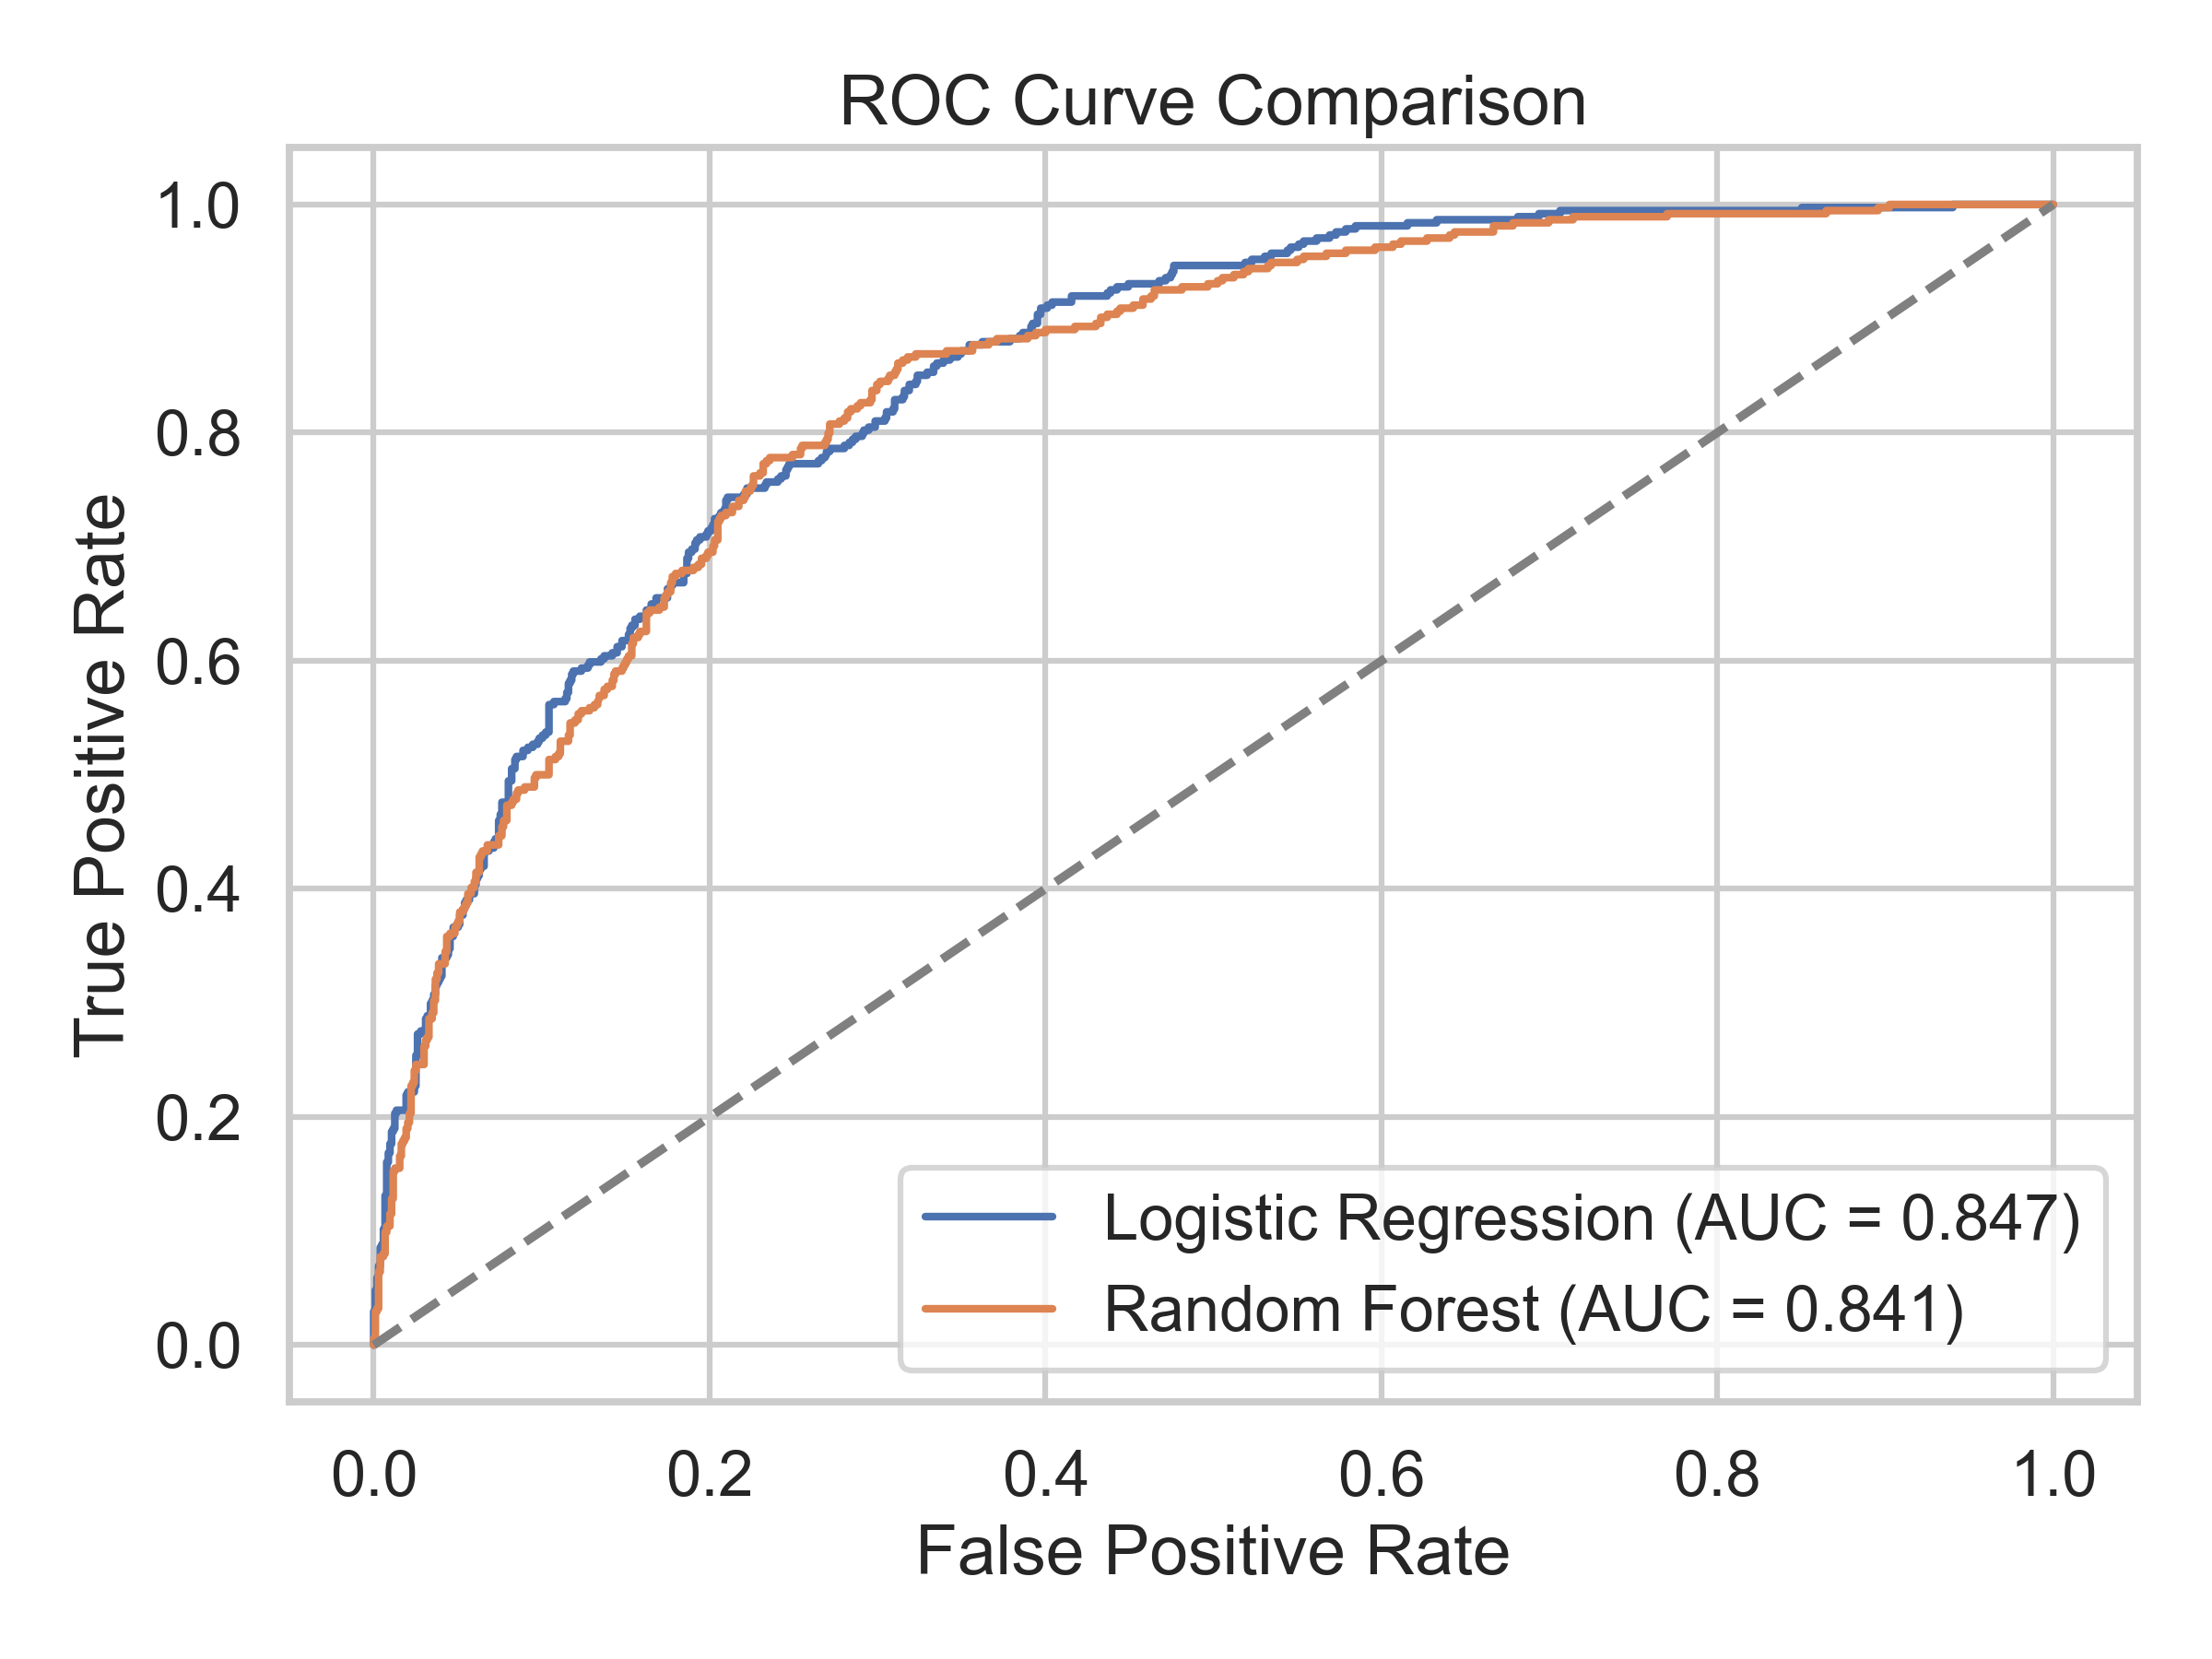

In [10]:
display(Image(filename='outputs/figures/model_performance.png'))
display(Image(filename='outputs/figures/confusion_matrices.png'))
display(Image(filename='outputs/figures/roc_curves.png'))

## 7. Model Interpretation
Interpretability matters for portfolio projects and real retention strategy. The logistic model shows directional impact, while the random forest highlights overall predictive importance.

In [11]:
logistic_df[['feature', 'coefficient']].head(10)

,feature,coefficient
42,cat__Contract_Two year,-0.882912
1,num__MonthlyCharges,-0.829290
20,cat__InternetService_Fiber optic,0.768284
40,cat__Contract_Month-to-month,0.750232
19,cat__InternetService_DSL,-0.665485
5,num__monthly_to_total_ratio,0.401009
3,num__total_services,0.278644
4,num__avg_monthly_charge_from_total,0.274068
56,cat__has_streaming_bundle_No,-0.252117
47,cat__PaymentMethod_Electronic check,0.243310


In [12]:
tree_df.head(10)

,feature,importance
40,cat__Contract_Month-to-month,0.092469
5,num__monthly_to_total_ratio,0.089269
0,num__tenure,0.073829
2,num__TotalCharges,0.067452
4,num__avg_monthly_charge_from_total,0.063800
1,num__MonthlyCharges,0.063166
42,cat__Contract_Two year,0.047947
22,cat__OnlineSecurity_No,0.046644
31,cat__TechSupport_No,0.041378
20,cat__InternetService_Fiber optic,0.039444


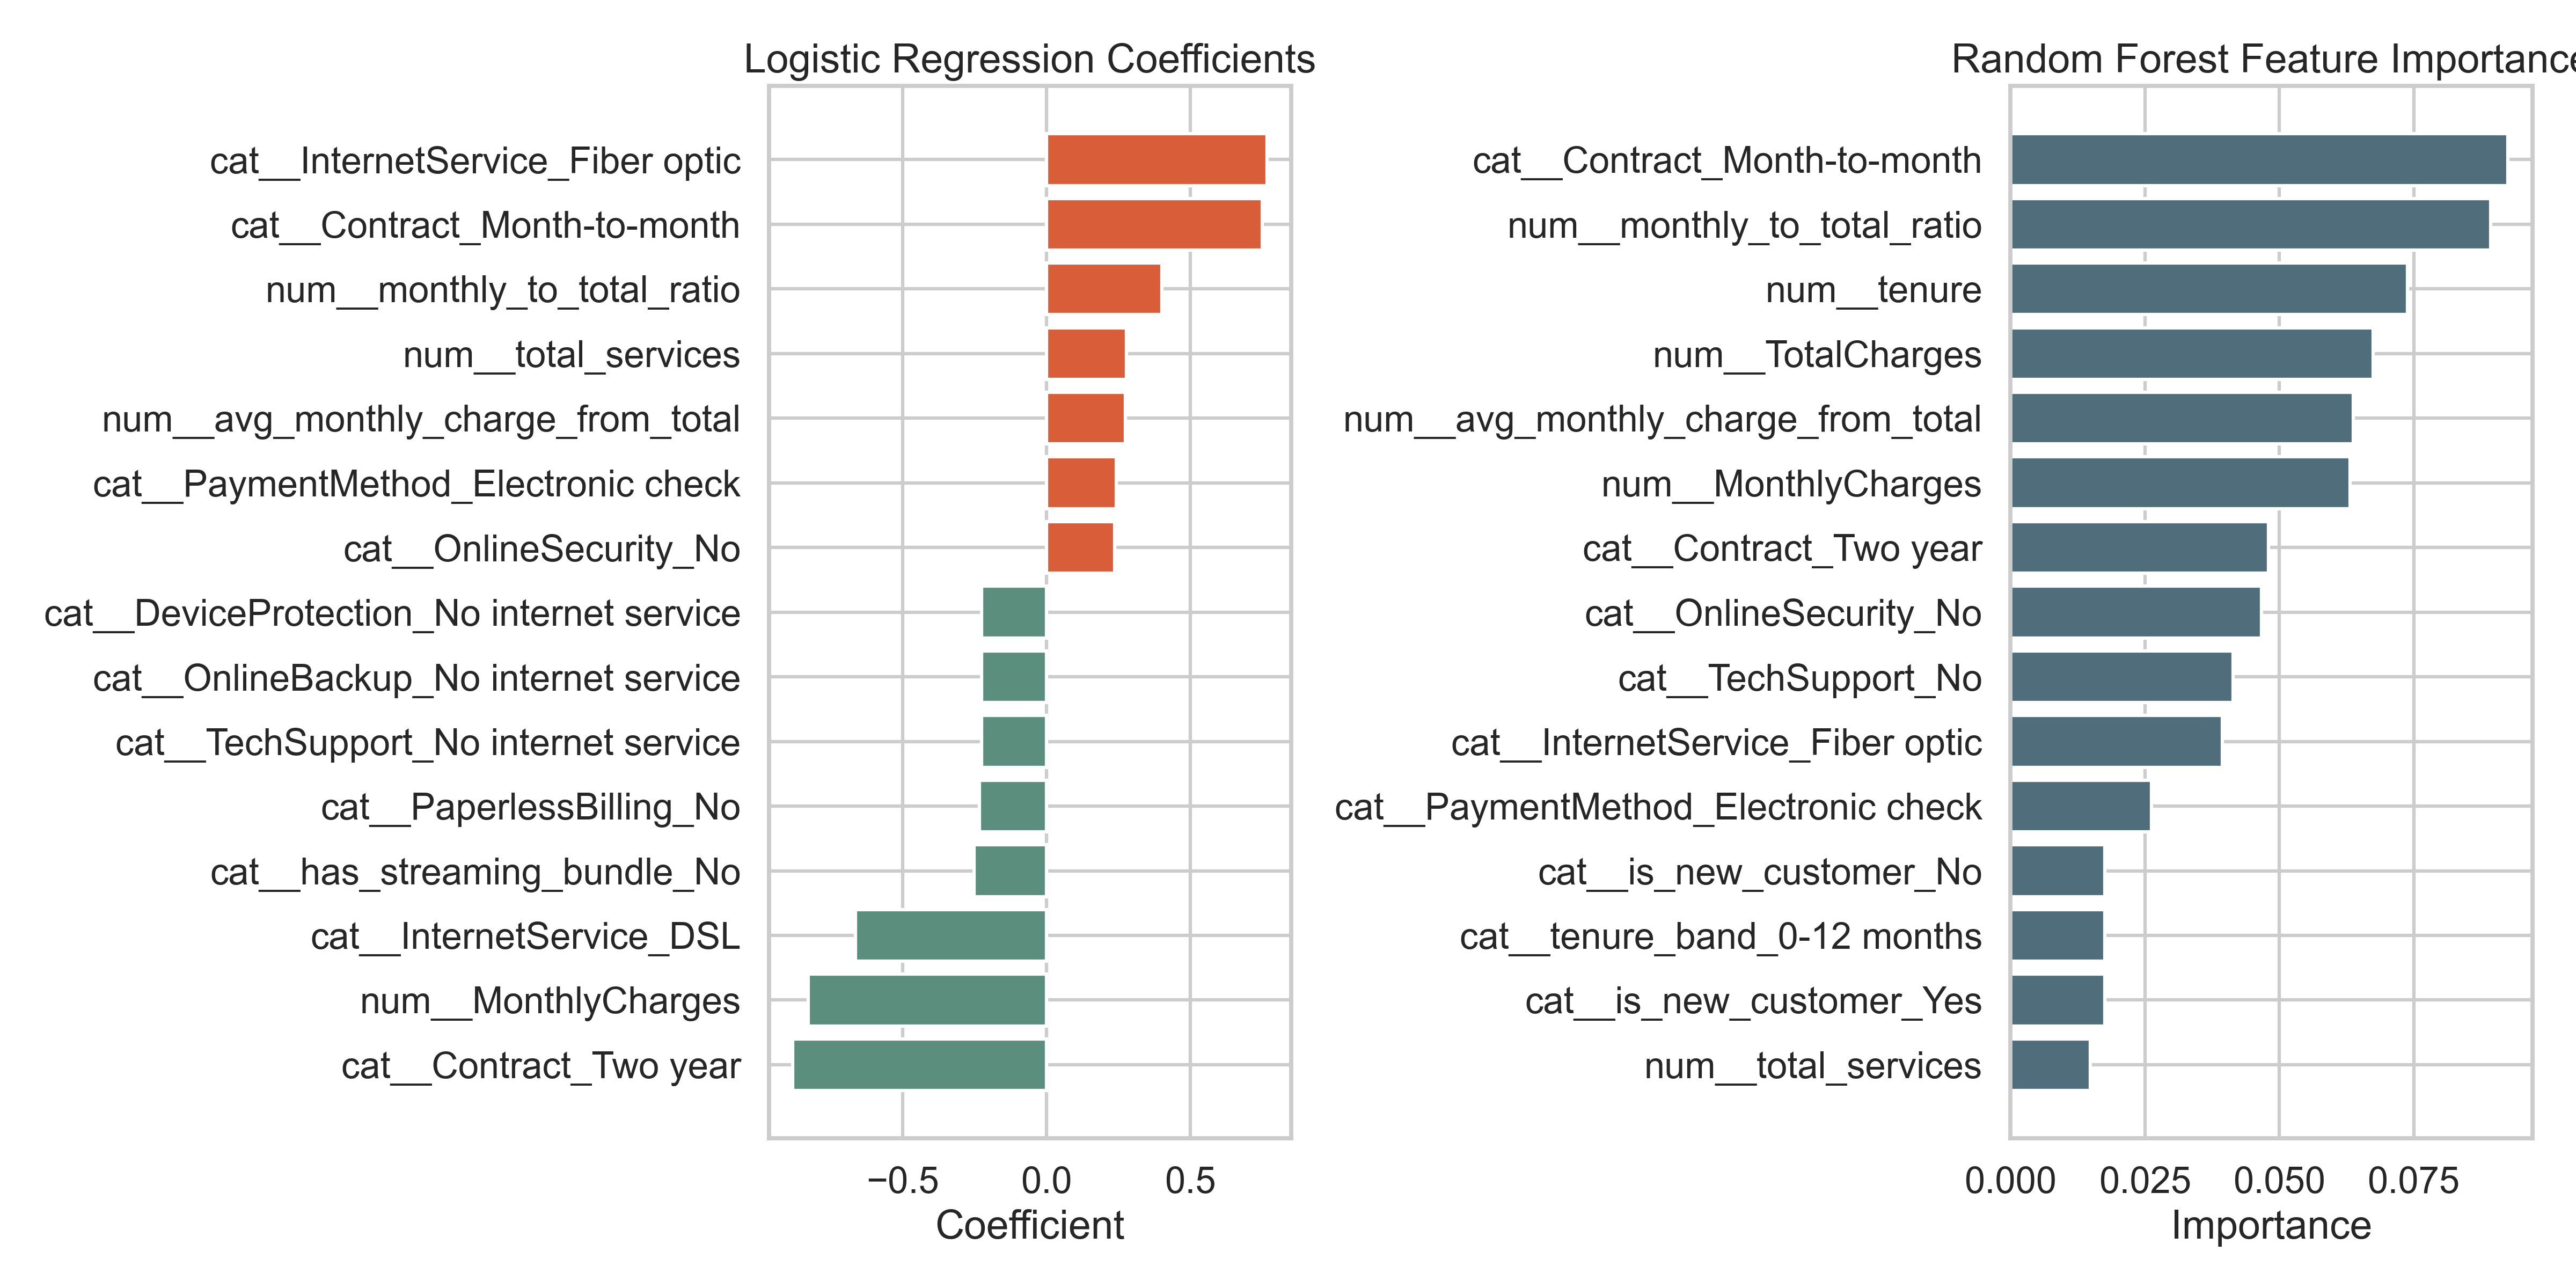

In [13]:
display(Image(filename='outputs/figures/feature_insights.png'))

## 8. Conclusion
Use the saved metrics and feature rankings to summarize churn drivers, model tradeoffs, and the business actions suggested by the analysis.

In [14]:
best_model = metrics_df.sort_values('roc_auc', ascending=False).iloc[0]
top_positive = logistic_df.sort_values('coefficient', ascending=False).head(5)[['feature', 'coefficient']]
top_tree = tree_df.head(5)

print(f"Best model by ROC AUC: {best_model['model']} ({best_model['roc_auc']:.3f})")
print('\nTop churn-increasing logistic coefficients:')
display(top_positive)
print('\nTop random forest importance drivers:')
display(top_tree)

Best model by ROC AUC: Logistic Regression (0.847)

Top churn-increasing logistic coefficients:


,feature,coefficient
20,cat__InternetService_Fiber optic,0.768284
40,cat__Contract_Month-to-month,0.750232
5,num__monthly_to_total_ratio,0.401009
3,num__total_services,0.278644
4,num__avg_monthly_charge_from_total,0.274068



Top random forest importance drivers:


,feature,importance
40,cat__Contract_Month-to-month,0.092469
5,num__monthly_to_total_ratio,0.089269
0,num__tenure,0.073829
2,num__TotalCharges,0.067452
4,num__avg_monthly_charge_from_total,0.063800
